Running Nash equilibrium enumeration...

  Nash Equilibria & Price of Anarchy  (C = 3)

  n = 3 devices
    beta   # NE    Opt W  Worst NE W     PoA
  ---------------------------------------------
     0.5      1    3.000       1.500   2.000
     1.0     17    3.000      -3.000     inf
     1.5      7    3.000       3.000   1.000
     2.0      7    3.000       3.000   1.000
     2.5      7    3.000       3.000   1.000
     3.0      7    3.000       3.000   1.000

  n = 4 devices
    beta   # NE    Opt W  Worst NE W     PoA
  ---------------------------------------------
     0.5      1    3.000      -2.000     inf
     1.0     66    3.000     -12.000     inf
     1.5     16    3.000       3.000   1.000
     2.0     16    3.000       3.000   1.000
     2.5     16    3.000       3.000   1.000
     3.0     16    3.000       3.000   1.000

  n = 5 devices
    beta   # NE    Opt W  Worst NE W     PoA
  ---------------------------------------------
     0.5      1    3.000      -7.500     in

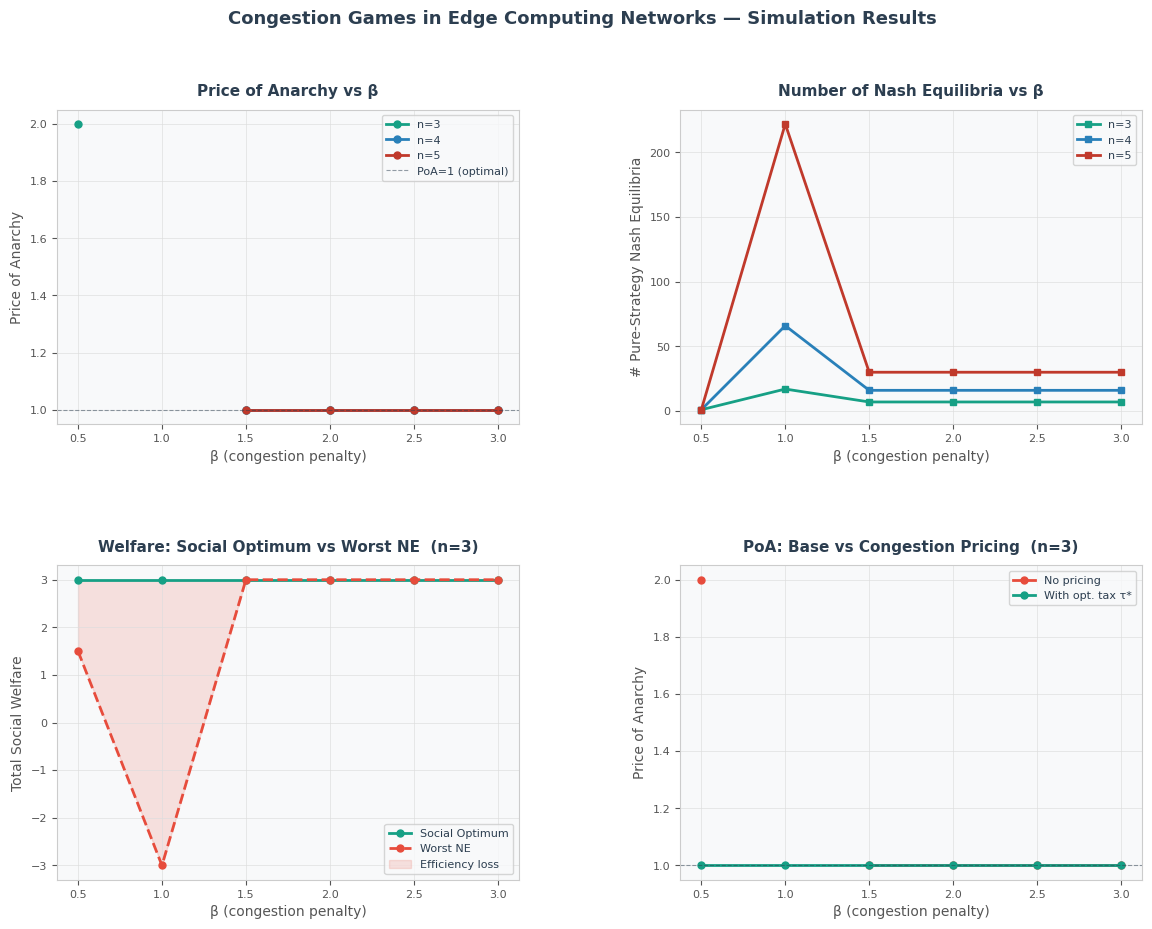

In [1]:
"""
Congestion Games in Edge Computing Networks
EE 513 - Game Theory for Interactive Autonomy
Syna Gogte

Simulation: Nash equilibrium enumeration, Price of Anarchy, and congestion pricing.

Payoff (base):   u_i = s_i - beta * max(0, S - C)
Payoff (taxed):  u_i = s_i - beta * max(0, S - C) - tau * s_i * 1[S > C]

Strategy set: s_i in {0, 1, 2}
"""

import itertools
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ─── Core payoff functions ────────────────────────────────────────────────────

def payoff(i, profile, beta, C):
    """Base payoff for device i given strategy profile (tuple)."""
    S = sum(profile)
    return profile[i] - beta * max(0, S - C)

def payoff_taxed(i, profile, beta, C, tau):
    """Taxed payoff for device i."""
    S = sum(profile)
    congested = 1 if S > C else 0
    return profile[i] - beta * max(0, S - C) - tau * profile[i] * congested

def social_welfare(profile, beta, C):
    """Total welfare across all devices."""
    return sum(payoff(i, profile, beta, C) for i in range(len(profile)))

# ─── Nash equilibrium enumeration ────────────────────────────────────────────

def is_nash(profile, beta, C, tau=0.0):
    """Check if a strategy profile is a pure-strategy Nash equilibrium."""
    n = len(profile)
    for i in range(n):
        if tau > 0:
            current = payoff_taxed(i, profile, beta, C, tau)
        else:
            current = payoff(i, profile, beta, C)
        for alt in [0, 1, 2]:
            if alt == profile[i]:
                continue
            alt_profile = tuple(profile[j] if j != i else alt for j in range(n))
            if tau > 0:
                alt_pay = payoff_taxed(i, alt_profile, beta, C, tau)
            else:
                alt_pay = payoff(i, alt_profile, beta, C)
            if alt_pay > current:
                return False
    return True

def find_nash_equilibria(n, beta, C, tau=0.0):
    """Enumerate all pure-strategy Nash equilibria for n players."""
    all_profiles = list(itertools.product([0, 1, 2], repeat=n))
    return [p for p in all_profiles if is_nash(p, beta, C, tau)]

def find_social_optimum(n, beta, C):
    """Find profile(s) maximizing total social welfare."""
    all_profiles = list(itertools.product([0, 1, 2], repeat=n))
    best_welfare = -np.inf
    best_profiles = []
    for p in all_profiles:
        w = social_welfare(p, beta, C)
        if w > best_welfare:
            best_welfare = w
            best_profiles = [p]
        elif w == best_welfare:
            best_profiles.append(p)
    return best_profiles, best_welfare

# ─── Price of Anarchy ─────────────────────────────────────────────────────────

def price_of_anarchy(n, beta, C, tau=0.0):
    """
    PoA = Social Optimum welfare / worst Nash equilibrium welfare.
    Returns (PoA, nash_equilibria, opt_welfare, worst_nash_welfare).
    """
    ne_list = find_nash_equilibria(n, beta, C, tau)
    _, opt_welfare = find_social_optimum(n, beta, C)

    if not ne_list:
        return None, [], opt_welfare, None

    nash_welfares = [social_welfare(p, beta, C) for p in ne_list]
    worst_nash_welfare = min(nash_welfares)

    if opt_welfare <= 0 or worst_nash_welfare <= 0:
        poa = float('inf')
    else:
        poa = opt_welfare / worst_nash_welfare

    return poa, ne_list, opt_welfare, worst_nash_welfare

# ─── Congestion pricing: find optimal tau ────────────────────────────────────

def find_optimal_tau(n, beta, C, tau_range=None):
    """
    Search for smallest tau where PoA of taxed game is minimized.
    Returns (best_tau, poa_at_best_tau).
    """
    if tau_range is None:
        tau_range = np.linspace(0, 3.0, 300)

    _, opt_welfare = find_social_optimum(n, beta, C)
    best_tau = 0.0
    best_poa = float('inf')

    for tau in tau_range:
        ne_taxed = find_nash_equilibria(n, beta, C, tau)
        if not ne_taxed:
            continue
        nash_welfares = [social_welfare(p, beta, C) for p in ne_taxed]
        worst = min(nash_welfares)
        if worst <= 0:
            continue
        poa = opt_welfare / worst
        if poa < best_poa:
            best_poa = poa
            best_tau = tau
        if abs(poa - 1.0) < 0.01:
            return tau, poa

    return best_tau, best_poa

# ─── Experiments ─────────────────────────────────────────────────────────────

def experiment_poa_vs_beta(n_values, beta_values, C):
    results = {}
    for n in n_values:
        results[n] = {}
        for beta in beta_values:
            poa, ne_list, opt_w, worst_w = price_of_anarchy(n, beta, C)
            results[n][beta] = {
                'poa': poa,
                'num_ne': len(ne_list),
                'opt_welfare': opt_w,
                'worst_nash_welfare': worst_w,
                'ne_list': ne_list,
            }
    return results

def experiment_pricing(n_values, beta_values, C):
    results = {}
    for n in n_values:
        results[n] = {}
        for beta in beta_values:
            poa_base, _, _, _ = price_of_anarchy(n, beta, C)
            opt_tau, poa_taxed = find_optimal_tau(n, beta, C)
            results[n][beta] = {
                'poa_base': poa_base,
                'poa_taxed': poa_taxed,
                'opt_tau': opt_tau,
            }
    return results

# ─── Printing ─────────────────────────────────────────────────────────────────

def print_results(results, C):
    print(f"\n{'='*65}")
    print(f"  Nash Equilibria & Price of Anarchy  (C = {C})")
    print(f"{'='*65}")
    for n, beta_data in results.items():
        print(f"\n  n = {n} devices")
        print(f"  {'beta':>6}  {'# NE':>5}  {'Opt W':>7}  {'Worst NE W':>10}  {'PoA':>6}")
        print(f"  {'-'*45}")
        for beta, d in sorted(beta_data.items()):
            poa_str   = f"{d['poa']:.3f}" if d['poa'] is not None else "N/A"
            worst_str = f"{d['worst_nash_welfare']:.3f}" if d['worst_nash_welfare'] is not None else "N/A"
            print(f"  {beta:>6.1f}  {d['num_ne']:>5}  {d['opt_welfare']:>7.3f}  {worst_str:>10}  {poa_str:>6}")

def print_pricing_results(pricing_results):
    print(f"\n{'='*60}")
    print(f"  Congestion Pricing: PoA Reduction")
    print(f"{'='*60}")
    for n, beta_data in pricing_results.items():
        print(f"\n  n = {n} devices")
        print(f"  {'beta':>6}  {'PoA (base)':>10}  {'opt tau':>8}  {'PoA (taxed)':>11}")
        print(f"  {'-'*42}")
        for beta, d in sorted(beta_data.items()):
            poa_b = f"{d['poa_base']:.3f}"  if d['poa_base']  else "N/A"
            poa_t = f"{d['poa_taxed']:.3f}" if d['poa_taxed'] else "N/A"
            tau_s = f"{d['opt_tau']:.3f}"   if d['opt_tau'] is not None else "N/A"
            print(f"  {beta:>6.1f}  {poa_b:>10}  {tau_s:>8}  {poa_t:>11}")

# ─── Plotting ─────────────────────────────────────────────────────────────────

def plot_results(results, pricing_results, C, beta_values, n_values):
    fig = plt.figure(figsize=(14, 10))
    fig.patch.set_facecolor('white')
    gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

    TEAL   = '#16A085'
    BLACK  = '#2C3E50'
    MUTED  = '#555555'
    BG     = '#F8F9FA'
    colors = ['#16A085', '#2980B9', '#C0392B', '#D35400']

    def style_ax(ax, title):
        ax.set_facecolor(BG)
        ax.set_title(title, color=BLACK, fontsize=11, fontweight='bold', pad=10)
        ax.tick_params(colors=MUTED, labelsize=8)
        ax.xaxis.label.set_color(MUTED)
        ax.yaxis.label.set_color(MUTED)
        for spine in ax.spines.values():
            spine.set_edgecolor('#CCCCCC')
        ax.grid(True, color='#DDDDDD', linewidth=0.5, alpha=0.9)

    # Plot 1: PoA vs beta for each n
    ax1 = fig.add_subplot(gs[0, 0])
    style_ax(ax1, "Price of Anarchy vs β")
    for i, n in enumerate(n_values):
        betas = sorted(results[n].keys())
        poas  = [results[n][b]['poa'] for b in betas]
        ax1.plot(betas, poas, marker='o', color=colors[i], label=f'n={n}', linewidth=2, markersize=5)
    ax1.axhline(1.0, color=BLACK, linewidth=0.8, linestyle='--', alpha=0.5, label='PoA=1 (optimal)')
    ax1.set_xlabel("β (congestion penalty)")
    ax1.set_ylabel("Price of Anarchy")
    ax1.legend(fontsize=8, facecolor=BG, labelcolor=BLACK, edgecolor='#CCCCCC')

    # Plot 2: Number of NE vs beta
    ax2 = fig.add_subplot(gs[0, 1])
    style_ax(ax2, "Number of Nash Equilibria vs β")
    for i, n in enumerate(n_values):
        betas  = sorted(results[n].keys())
        num_ne = [results[n][b]['num_ne'] for b in betas]
        ax2.plot(betas, num_ne, marker='s', color=colors[i], label=f'n={n}', linewidth=2, markersize=5)
    ax2.set_xlabel("β (congestion penalty)")
    ax2.set_ylabel("# Pure-Strategy Nash Equilibria")
    ax2.legend(fontsize=8, facecolor=BG, labelcolor=BLACK, edgecolor='#CCCCCC')

    # Plot 3: Welfare comparison for n=3
    ax3 = fig.add_subplot(gs[1, 0])
    style_ax(ax3, "Welfare: Social Optimum vs Worst NE  (n=3)")
    betas    = sorted(results[3].keys())
    opt_ws   = [results[3][b]['opt_welfare'] for b in betas]
    worst_ws = [results[3][b]['worst_nash_welfare'] for b in betas]
    ax3.plot(betas, opt_ws,   marker='o', color=TEAL,      label='Social Optimum', linewidth=2, markersize=5)
    ax3.plot(betas, worst_ws, marker='o', color='#E74C3C', label='Worst NE',       linewidth=2, markersize=5, linestyle='--')
    ax3.fill_between(betas, worst_ws, opt_ws, alpha=0.15, color='#E74C3C', label='Efficiency loss')
    ax3.set_xlabel("β (congestion penalty)")
    ax3.set_ylabel("Total Social Welfare")
    ax3.legend(fontsize=8, facecolor=BG, labelcolor=BLACK, edgecolor='#CCCCCC')

    # Plot 4: PoA before vs after pricing for n=3
    ax4 = fig.add_subplot(gs[1, 1])
    style_ax(ax4, "PoA: Base vs Congestion Pricing  (n=3)")
    betas     = sorted(pricing_results[3].keys())
    poa_base  = [pricing_results[3][b]['poa_base']  for b in betas]
    poa_taxed = [pricing_results[3][b]['poa_taxed'] for b in betas]
    ax4.plot(betas, poa_base,  marker='o', color='#E74C3C', label='No pricing',       linewidth=2, markersize=5)
    ax4.plot(betas, poa_taxed, marker='o', color=TEAL,      label='With opt. tax τ*', linewidth=2, markersize=5)
    ax4.axhline(1.0, color=BLACK, linewidth=0.8, linestyle='--', alpha=0.5)
    ax4.set_xlabel("β (congestion penalty)")
    ax4.set_ylabel("Price of Anarchy")
    ax4.legend(fontsize=8, facecolor=BG, labelcolor=BLACK, edgecolor='#CCCCCC')

    fig.suptitle("Congestion Games in Edge Computing Networks — Simulation Results",
                 color=BLACK, fontsize=13, fontweight='bold', y=0.98)

    # out = "/mnt/user-data/outputs/simulation_results.png"
    # plt.savefig(out, dpi=150, bbox_inches='tight', facecolor='white')
    # print(f"\nPlot saved to {out}")

# ─── Main ─────────────────────────────────────────────────────────────────────

if __name__ == "__main__":
    C           = 3
    n_values    = [3, 4, 5]
    beta_values = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]

    print("Running Nash equilibrium enumeration...")
    results = experiment_poa_vs_beta(n_values, beta_values, C)
    print_results(results, C)

    print("\nNash Equilibrium profiles for n=3:")
    print(f"{'='*65}")
    for beta in [0.5, 1.0, 2.0]:
        ne_list = results[3][beta]['ne_list']
        print(f"\n  beta={beta}: {len(ne_list)} NE found")
        for p in ne_list:
            w = social_welfare(p, beta, C)
            S = sum(p)
            print(f"    profile={p}  S={S}  welfare={w:.3f}")

    print("\nRunning congestion pricing analysis...")
    pricing_results = experiment_pricing(n_values, beta_values, C)
    print_pricing_results(pricing_results)

    print("\nGenerating plots...")
    plot_results(results, pricing_results, C, beta_values, n_values)
    print("\nDone.")